In [1]:
import sys
import os
from tqdm import tqdm
# tambahin root project ke path
sys.path.append(os.path.abspath(".."))

In [2]:
from utils.dataloader import get_dataloader

In [3]:
BASE_DIR = os.path.abspath("..")

train_path = os.path.join(BASE_DIR, "data/WLBisindo/split/train")
val_path   = os.path.join(BASE_DIR, "data/WLBisindo/split/val")
test_path  = os.path.join(BASE_DIR, "data/WLBisindo/split/test")

print(train_path)

D:\Softwares\AnacondaProjects\GestureSequenceCNN\data/WLBisindo/split/train


In [4]:
import os

print("Train exists:", os.path.exists(train_path))
print("Val exists:", os.path.exists(val_path))
print("Test exists:", os.path.exists(test_path))

Train exists: True
Val exists: True
Test exists: True


In [5]:
from utils.dataloader import get_dataloader, get_transforms

train_transform, val_transform = get_transforms()

train_loader, train_dataset = get_dataloader(
    train_path,
    transform=train_transform,
    use_weighted_sampler=True
)

val_loader, val_dataset = get_dataloader(
    val_path,
    transform=val_transform,
    use_weighted_sampler=False
)

test_loader, test_dataset = get_dataloader(
    test_path,
    transform=val_transform,
    use_weighted_sampler=False
)

Class counts: [34 14 32 35 23 30 34 28 13 35 27 32 34 12 21 28 24 29 32 28 25 22 31 14
 35 33 30 26 35 33 32 32]


In [6]:
for x, y in train_loader:
    print("Input shape :", x.shape)  # (B, 20, 3, 224, 224)
    print("Label shape :", y.shape) # (B,)
    print("Label sample:", y[:5])
    break

Input shape : torch.Size([8, 20, 6, 224, 224])
Label shape : torch.Size([8])
Label sample: tensor([24, 26, 17, 19, 10])


In [7]:
import os
import numpy as np
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

# buat folder run unik
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

BASE_DIR = os.path.abspath("..")
log_dir = os.path.join(BASE_DIR, "outputs/logs/cnn_lstm", f"run_{timestamp}")

os.makedirs(log_dir, exist_ok=True)

writer = SummaryWriter(log_dir)

print("Log dir:", log_dir)

Log dir: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/logs/cnn_lstm\run_20260415_162628


In [8]:
log_file = os.path.join(log_dir, "log.txt")

def log_message(msg):
    print(msg)
    with open(log_file, "a") as f:
        f.write(msg + "\n")

In [9]:
# ambil jumlah kelas dari dataset
NUM_CLASSES = len(train_loader.dataset.label_map)

print("Num classes:", NUM_CLASSES)

print("Class distribution:", np.bincount(train_dataset.labels))

Num classes: 32
Class distribution: [34 14 32 35 23 30 34 28 13 35 27 32 34 12 21 28 24 29 32 28 25 22 31 14
 35 33 30 26 35 33 32 32]


In [10]:
from models.cnn_lstm import CNN_LSTM

model = CNN_LSTM(num_classes=NUM_CLASSES)

x, y = next(iter(train_loader))
out = model(x)

print(out.shape)

torch.Size([8, 32])


In [11]:
import torch
import numpy as np
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = CNN_LSTM(num_classes=NUM_CLASSES).to(device)

for param in model.encoder.cnn.parameters():
    param.requires_grad = True

# ambil label dari dataset
labels = train_dataset.labels
class_counts = np.bincount(labels)

weights = 1.0 / class_counts

# NORMALIZE
weights = weights / weights.sum() * len(weights)

# CLASS 12 Supported
weights[12] = weights[12] * 3.0  # bisa coba 2.0 - 5.0

weights = torch.tensor(weights, dtype=torch.float).to(device)

weights = torch.tensor(weights, dtype=torch.float).to(device)

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = torch.nn.CrossEntropyLoss(weight=alpha)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss

criterion = FocalLoss(alpha=weights, gamma=2)

print("Class weights:", weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

Device: cuda
Class weights: tensor([0.7489, 1.8187, 0.7957, 0.7275, 1.1071, 0.8487, 0.7489, 0.9094, 1.9586,
        0.7275, 0.9430, 0.7957, 2.2467, 2.1219, 1.2125, 0.9094, 1.0609, 0.8780,
        0.7957, 0.9094, 1.0185, 1.1574, 0.8214, 1.8187, 0.7275, 0.7716, 0.8487,
        0.9793, 0.7275, 0.7716, 0.7957, 0.7957], device='cuda:0')


C:\Users\Axioo Pongo\AppData\Local\Temp\ipykernel_13888\1860190095.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weights = torch.tensor(weights, dtype=torch.float).to(device)


In [12]:
def compute_accuracy(preds, labels):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == labels).sum().item()
    return correct / len(labels)

In [13]:
EPOCHS = 50
patience = 3
counter = 0
best_val_loss = float("inf")

import json

config = {
    "model": "CNN_LSTM",
    "epochs": EPOCHS,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "batch_size": train_loader.batch_size,
    "num_classes": NUM_CLASSES,
    "cnn_unfreeze": True
}

with open(os.path.join(log_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for x, y in train_bar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

        # update progress bar
        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in val_bar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

            # update progress bar
            val_bar.set_postfix({
                "loss": f"{loss.item():.4f}"
            })

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # ===== LOGGING =====
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)

    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)

    writer.add_scalar("Overfitting/gap", train_acc - val_acc, epoch)

    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar("LR", current_lr, epoch)

    for name, param in model.named_parameters():
        writer.add_histogram(f"Weights/{name}", param, epoch)

        if param.grad is not None:
            writer.add_histogram(f"Gradients/{name}", param.grad, epoch)

    log_message(f"Epoch {epoch+1}/{EPOCHS}")
    log_message(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    log_message(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
    log_message(f"LR: {current_lr}")
    log_message("-" * 40)

    # ===== SCHEDULER =====
    scheduler.step(val_loss)


    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), os.path.join(log_dir, "best_model.pth"))
        log_message("Best model saved!")

    else:
        counter += 1
        log_message(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            log_message("Early stopping triggered!")
            break


# SAVE LAST MODEL
torch.save(model.state_dict(), os.path.join(log_dir, "last_model.pth"))


Epoch 1/50


Epoch 1/50
Train Loss: 3.1648 | Acc: 0.0638
Val   Loss: 2.7400 | Acc: 0.1538
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 2/50


Epoch 2/50
Train Loss: 2.3166 | Acc: 0.2206
Val   Loss: 1.8081 | Acc: 0.3462
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 3/50


Epoch 3/50
Train Loss: 1.7570 | Acc: 0.3561
Val   Loss: 1.2313 | Acc: 0.4505
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 4/50


Epoch 4/50
Train Loss: 1.2480 | Acc: 0.4938
Val   Loss: 0.6400 | Acc: 0.6703
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 5/50


...

Epoch 8/50
Train Loss: 0.2696 | Acc: 0.8186
Val   Loss: 0.2181 | Acc: 0.8407
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 9/50


Epoch 9/50
Train Loss: 0.2164 | Acc: 0.8175
Val   Loss: 0.1157 | Acc: 0.8681
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 10/50


Epoch 10/50
Train Loss: 0.1235 | Acc: 0.8824
Val   Loss: 0.2102 | Acc: 0.8516
LR: 0.0001
----------------------------------------
EarlyStopping counter: 1/3

Epoch 11/50


Epoch 11/50
Train Loss: 0.1086 | Acc: 0.8925
Val   Loss: 0.1852 | Acc: 0.8681
LR: 0.0001
----------------------------------------
EarlyStopping counter: 2/3

Epoch 12/50


Epoch 12/50
Train Loss: 0.0830 | Acc: 0.9071
Val   Loss: 0.2660 | Acc: 0.8791
LR: 0.0001
----------------------------------------
EarlyStopping counter: 3/3
Early stopping triggered!


In [14]:
from utils.evaluate import evaluate

report_path = os.path.join(log_dir, "evaluation.json")

metrics = evaluate(
    model,
    test_loader,
    device,
    save_path=report_path,
    model_name="CNNResNetLSTM"
)

Evaluation Metrics:
accuracy: 0.8969
precision: 0.9182
recall: 0.9014
f1: 0.8931
hamming_loss: 0.1031
Experiment logged to: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/metrics\experiments.csv


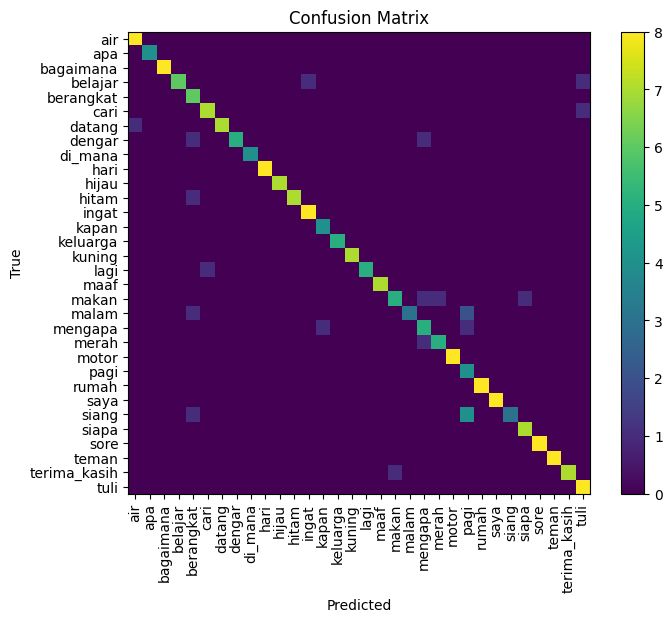

In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

# plot
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")

labels = list(train_loader.dataset.label_map.keys())

plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)

plt.savefig(os.path.join(log_dir, "confusion_matrix.png"))
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

from collections import Counter

print("Predicted distribution:", Counter(y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         8
           3       1.00      0.75      0.86         8
           4       0.60      1.00      0.75         6
           5       0.88      0.88      0.88         8
           6       1.00      0.88      0.93         8
           7       1.00      0.71      0.83         7
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         7
          11       1.00      0.88      0.93         8
          12       0.89      1.00      0.94         8
          13       0.80      1.00      0.89         4
          14       1.00      1.00      1.00         5
          15       1.00      1.00      1.00         7
          16       1.00      0.83      0.91         6
          17       1.00    

In [17]:
print("True count:", Counter(y_true))
print("Pred count:", Counter(y_pred))

True count: Counter({np.int64(31): 8, np.int64(9): 8, np.int64(6): 8, np.int64(24): 8, np.int64(28): 8, np.int64(5): 8, np.int64(30): 8, np.int64(0): 8, np.int64(11): 8, np.int64(18): 8, np.int64(29): 8, np.int64(26): 8, np.int64(25): 8, np.int64(22): 8, np.int64(2): 8, np.int64(12): 8, np.int64(3): 8, np.int64(10): 7, np.int64(15): 7, np.int64(17): 7, np.int64(7): 7, np.int64(27): 7, np.int64(20): 7, np.int64(19): 6, np.int64(4): 6, np.int64(21): 6, np.int64(16): 6, np.int64(14): 5, np.int64(8): 4, np.int64(13): 4, np.int64(23): 4, np.int64(1): 4})
Pred count: Counter({np.int64(23): 11, np.int64(31): 10, np.int64(4): 10, np.int64(0): 9, np.int64(12): 9, np.int64(9): 8, np.int64(24): 8, np.int64(28): 8, np.int64(5): 8, np.int64(29): 8, np.int64(25): 8, np.int64(22): 8, np.int64(27): 8, np.int64(2): 8, np.int64(20): 8, np.int64(6): 7, np.int64(10): 7, np.int64(15): 7, np.int64(17): 7, np.int64(30): 7, np.int64(11): 7, np.int64(18): 6, np.int64(21): 6, np.int64(3): 6, np.int64(14): 5, np